# Tiny-circuit sweep

A minimal test problem: one brickwork circuit with **5 wires, depth 3**,
trained on a **single depth-3 output wire** using the solo-output methodology
from `solo_grokking.ipynb` (loss masked to that wire; eval still records all
5 outputs). Circuit seed 5 gives tap depths [3, 3, 1, 3, 2] with a real gate
in the last layer acting on wires 0, 1, 3; the target is **wire 0**, a
balanced function of all 5 inputs (verified below).

Sweeps 7 model shapes from the `sweep.py` scale grid at their tuned LRs
(`runs/lr_table.json`). With only 2^5 = 32 distinct inputs, a 256-batch
covers the whole input space ~8x per step, so train and eval distributions
coincide — expect fast saturation at every size. Use this as a pipeline
smoke test and a lower anchor for model-size scaling, not as a
generalization measurement.

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import os
    %pip -q install -U "jax[cuda12]" optax
    if not os.path.exists("/content/circscale"):
        !git clone https://github.com/amdson/circscale.git /content/circscale
    %cd /content/circscale
    !git pull
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs("/content/drive/MyDrive/circscale_runs", exist_ok=True)
    if not os.path.islink("runs"):
        os.symlink("/content/drive/MyDrive/circscale_runs", "runs")

## The circuit

Rebuilds exactly the circuit `train.py` will sample (same seeded RNG path)
and inspects the target output: tap depths, balance, relevant inputs,
Fourier degree, and the full 32-row truth table.

In [2]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np

from random_circuit import evaluate_np, sample_circuit
from train import RunConfig, load_run, run

# --- task: one tiny circuit, one output wire ---
N_WIRES, CIRC_DEPTH = 5, 3
CIRCUIT_SEED = 5
TARGET_WIRE = 0

circuit = sample_circuit(np.random.default_rng(CIRCUIT_SEED), N_WIRES, CIRC_DEPTH)
X = np.array(list(product([0, 1], repeat=N_WIRES)), dtype=np.uint8)  # all 32 inputs
Y = evaluate_np(circuit, X)
y = Y[:, TARGET_WIRE]

print("tap depths:", circuit.out_depths,
      f"-> target wire {TARGET_WIRE} at depth {circuit.out_depths[TARGET_WIRE]}")
print(f"balance: {y.mean():.3f}")

flip = np.eye(N_WIRES, dtype=np.uint8)
powers = 1 << np.arange(N_WIRES)[::-1]          # X rows are sorted by this key
rel = [i for i in range(N_WIRES) if np.any(y != y[(X ^ flip[i]) @ powers])]
print("relevant inputs:", rel)

subsets = X.astype(int)                          # reuse the 32 rows as subset masks
signs = 1 - 2 * X.astype(int)                    # inputs in +/-1
chi = np.prod(np.where(subsets[:, None, :] == 1, signs[None, :, :], 1), axis=2)
coeffs = chi @ (1 - 2 * y.astype(int)) / len(X)  # Fourier coefficients over all S
print("Fourier degree:", subsets[np.abs(coeffs) > 1e-9].sum(axis=1).max())
print("truth table:", "".join(map(str, y)))

tap depths: [3 3 1 3 2] -> target wire 0 at depth 3
balance: 0.500
relevant inputs: [0, 1, 2, 3, 4]
Fourier degree: 4
truth table: 01011101001101110111000000010101


/Users/amdson/dev/satscaling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Sweep: 7 model sizes, tuned LRs

Shapes from the `sweep.py` scale grid; each LR is that shape's tuned value
from `runs/lr_table.json`.

In [3]:
# (width, mlp_depth, lr) — LRs from runs/lr_table.json (sweep.py lr-tune)
SHAPES = [
    (32,  2, 1e-2),
    (64,  3, 1e-2),
    (128, 4, 3e-3),
    (180, 5, 3e-3),
    (256, 6, 1e-3),
    (360, 7, 1e-3),
    (512, 8, 1e-3),
]
STEPS = 10_000
OUT_DIR = "runs/tiny5"


def n_params(w, d, n_in=N_WIRES, n_out=N_WIRES, hr=4):
    h = hr * w
    return n_in * w + d * (w + w * h + h * w) + w + w * n_out


configs = [
    RunConfig(width=w, mlp_depth=d, lr=lr, steps=STEPS,
              n_wires=N_WIRES, circ_depth=CIRC_DEPTH, circuit_seed=CIRCUIT_SEED,
              output_wires=(TARGET_WIRE,), eval_every=100, out_dir=OUT_DIR)
    for w, d, lr in SHAPES
]
print(f"{'shape':>8s} {'lr':>7s} {'params':>12s}")
for (w, d, lr), cfg in zip(SHAPES, configs):
    print(f"{f'w{w}d{d}':>8s} {lr:>7g} {n_params(w, d):>12,d}")
print(f"\n{len(configs)} runs x {STEPS:,} steps -> {OUT_DIR}/")

   shape      lr       params
   w32d2    0.01       16,800
   w64d3    0.01       99,200
  w128d4   0.003      526,208
  w180d5   0.003    1,298,880
  w256d6   0.001    3,150,080
  w360d7   0.001    7,264,080
  w512d8   0.001   16,786,944

7 runs x 10,000 steps -> runs/tiny5/


## Run (idempotent — interrupt and re-run freely)

In [4]:
for cfg in configs:
    run(cfg)

w32_d2_b256_lr0.01_s10000_c5x3_ow0_cs5_ms0: 100%|██████████| 10000/10000 [00:07<00:00, 1277.17it/s, train=0.0000]


[done] w32_d2_b256_lr0.01_s10000_c5x3_ow0_cs5_ms0: eval loss 0.6849, acc 0.6021, 0.1 min


w64_d3_b256_lr0.01_s10000_c5x3_ow0_cs5_ms0: 100%|██████████| 10000/10000 [00:28<00:00, 345.56it/s, train=0.0000]


[done] w64_d3_b256_lr0.01_s10000_c5x3_ow0_cs5_ms0: eval loss 0.7102, acc 0.6042, 0.5 min


w128_d4_b256_lr0.003_s10000_c5x3_ow0_cs5_ms0: 100%|██████████| 10000/10000 [01:11<00:00, 140.74it/s, train=0.0000]


[done] w128_d4_b256_lr0.003_s10000_c5x3_ow0_cs5_ms0: eval loss 0.7187, acc 0.5879, 1.2 min


w180_d5_b256_lr0.003_s10000_c5x3_ow0_cs5_ms0: 100%|██████████| 10000/10000 [02:33<00:00, 65.17it/s, train=0.0000]


[done] w180_d5_b256_lr0.003_s10000_c5x3_ow0_cs5_ms0: eval loss 0.6274, acc 0.6042, 2.6 min


w256_d6_b256_lr0.001_s10000_c5x3_ow0_cs5_ms0:  13%|█▎        | 1314/10000 [00:43<04:49, 30.00it/s, train=0.0000]


KeyboardInterrupt: 

## Target-wire trajectories

Left: eval BCE on the target wire vs samples D, one curve per model size
(chance dotted). Right: final loss vs parameter count.

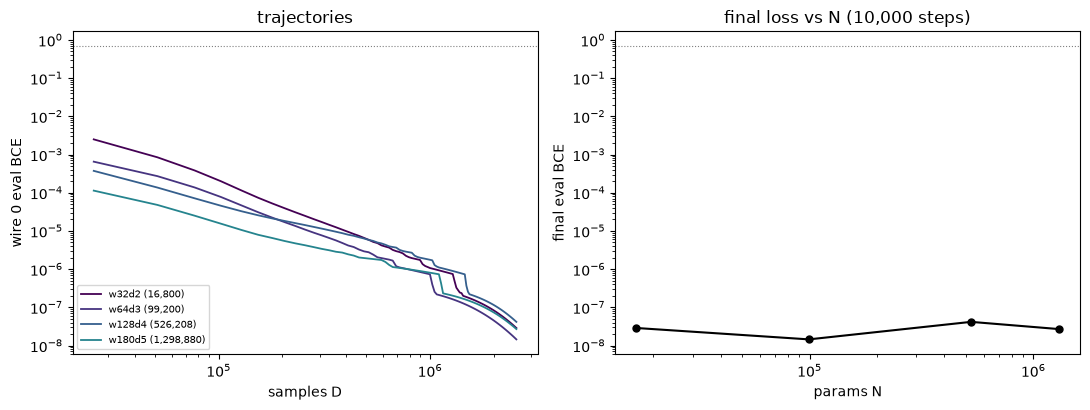

In [5]:
CHANCE = np.log(2)
data = {}
for (w, d, lr), cfg in zip(SHAPES, configs):
    if cfg.npz_path.exists():
        data[(w, d)] = load_run(cfg.npz_path)[1]

cols = plt.cm.viridis(np.linspace(0, 0.9, len(SHAPES)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for (w, d, lr), col in zip(SHAPES, cols):
    if (w, d) not in data:
        continue
    r = data[(w, d)]
    m = r["eval_steps"] > 0
    D = r["eval_steps"][m] * configs[0].batch
    ax1.plot(D, r["per_out_loss"][m][:, TARGET_WIRE], color=col, lw=1.3,
             label=f"w{w}d{d} ({n_params(w, d):,})")
ax1.axhline(CHANCE, color="gray", ls=":", lw=0.8)
ax1.set(xscale="log", yscale="log", xlabel="samples D",
        ylabel=f"wire {TARGET_WIRE} eval BCE", title="trajectories")
ax1.legend(fontsize=7)

Ns = [n_params(w, d) for w, d, _ in SHAPES if (w, d) in data]
finals = [data[(w, d)]["per_out_loss"][-1, TARGET_WIRE]
          for w, d, _ in SHAPES if (w, d) in data]
ax2.plot(Ns, finals, "ko-", ms=5)
ax2.axhline(CHANCE, color="gray", ls=":", lw=0.8)
ax2.set(xscale="log", yscale="log", xlabel="params N",
        ylabel="final eval BCE", title=f"final loss vs N ({STEPS:,} steps)")
plt.tight_layout()

## Transition times

First D where the target's eval BCE crosses below 0.2 nats (NaN = never).

In [ ]:
def transition_D(steps, loss, batch, thresh=0.2):
    below = np.flatnonzero(loss < thresh)
    return steps[below[0]] * batch if len(below) else np.nan


print(f"{'shape':>8s} {'params':>12s} {'transition D':>13s} {'final acc':>10s}")
for w, d, lr in SHAPES:
    if (w, d) not in data:
        continue
    r = data[(w, d)]
    t = transition_D(r["eval_steps"], r["per_out_loss"][:, TARGET_WIRE],
                     configs[0].batch)
    print(f"{f'w{w}d{d}':>8s} {n_params(w, d):>12,d} {t:>13,.0f} "
          f"{r['per_out_acc'][-1, TARGET_WIRE]:>10.3f}")

## Notes

- 32 distinct inputs at batch 256 means every step sees the whole input
  space ~8x: train and eval coincide, so read these curves as
  optimization / feature-learning speed, not sample efficiency.
- Non-target head columns get no gradient (solo masking), so `per_out_loss`
  on wires 1–4 reflects init noise — don't read incidental learning off them.
- One model seed per shape (`ms0`), matching `sweep.py`; pass extra
  `model_seed=` configs if a shape looks anomalous.